# Analysis Based on Different Quantiles
Here I care about the consistency across multiple runs that use a different quantile approach from the defualt 25 50 75 estimation points. 

In [4]:

# # This uses a quick script I made to reparse the json into whatever format I am testing instead of the default 25 50 75 format.
# # this is pretty quick and dirty, but good enough for a proof of concept. 

# import subprocess, sys
# from pathlib import Path

# percentiles = [20, 40, 60, 80]

# for path in Path("output_data_quintiles/runs").glob("*/full_results.json"):
#     print(f"Reparsing {path}...")
#     subprocess.run(
#         [sys.executable, "reparse_estimations.py", str(path), "--inplace",
#          "--percentiles", *map(str, percentiles)],
#         check=True
#     )



## Start of analysis code

In [5]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re
from collections import defaultdict

from consistency_metrics import plot_cdf_pairs, plot_pdf_pairs, row_to_pairs, compute_pairwise_metrics


PROJECT_ROOT = Path("..").resolve()
RUNS_DIR = PROJECT_ROOT / "output_data" / "runs"
QUINTILES_RUN = PROJECT_ROOT / "consistency_checks" / "output_data_quintiles" / "runs"
records = []

for run_dir in sorted(RUNS_DIR.glob("*")):
    json_path = run_dir / "full_results.json"
    if not json_path.exists():
        continue

    with open(json_path) as f:
        data = json.load(f)

    run_id = run_dir.name
    config = data["run_metadata"]["config_used"]
    model = config["llm_settings"]["model"]

    for step in data["results_per_step"]:
        step_name = step["step_name"]
        for task in step["results_per_task"]:
            task_name = task["task_name"]
            final_round = task["rounds_data"][-1]
            responses = final_round["responses"]

            # Collect all percentile_* values from parsed_estimation across experts
            percentile_lists = defaultdict(list)
            for r in responses:
                pe = r.get("parsed_estimation", {})
                for key, val in pe.items():
                    if key.startswith("percentile_") and isinstance(val, (int, float)):
                        percentile_lists[key].append(val)

            record = {
                "run_id": run_id,
                "model": model,
                "step_name": step_name,
                "task_name": task_name,
                "n_experts": len(responses),
                "final_prob": task["final_aggregated_probability"],
            }
            for key, vals in sorted(percentile_lists.items()):
                record[key] = vals
                record[f"{key}_mean"] = np.mean(vals) if vals else np.nan

            records.append(record)

df = pd.DataFrame(records)
print(f"Loaded {len(df)} records from {df['run_id'].nunique()} runs")

percentile_cols = sorted(c for c in df.columns if c.startswith("percentile_") and not c.endswith("_mean"))
mean_cols = [f"{c}_mean" for c in percentile_cols]
display(df[["run_id", "model", "step_name", "task_name", "n_experts"] + percentile_cols + mean_cols].head(5))

records_quintiles = []

for run_dir in sorted(QUINTILES_RUN.glob("*")):
    json_path = run_dir / "full_results.json"
    if not json_path.exists():
        continue

    with open(json_path) as f:
        data = json.load(f)

    run_id = run_dir.name
    config = data["run_metadata"]["config_used"]
    model = config["llm_settings"]["model"]

    for step in data["results_per_step"]:
        step_name = step["step_name"]
        for task in step["results_per_task"]:
            task_name = task["task_name"]
            final_round = task["rounds_data"][-1]
            responses = final_round["responses"]

            percentile_lists = defaultdict(list)
            for r in responses:
                pe = r.get("parsed_estimation", {})
                for key, val in pe.items():
                    if key.startswith("percentile_") and isinstance(val, (int, float)):
                        percentile_lists[key].append(val)

            record = {
                "run_id": run_id,
                "model": model,
                "step_name": step_name,
                "task_name": task_name,
                "n_experts": len(responses),
                "final_prob": task["final_aggregated_probability"],
            }
            for key, vals in sorted(percentile_lists.items()):
                record[key] = vals
                record[f"{key}_mean"] = np.mean(vals) if vals else np.nan

            records_quintiles.append(record)

df_quintiles = pd.DataFrame(records_quintiles)
print(f"Loaded {len(df_quintiles)} quintile records from {df_quintiles['run_id'].nunique()} runs")

percentile_cols_q = sorted(c for c in df_quintiles.columns if c.startswith("percentile_") and not c.endswith("_mean"))
mean_cols_q = [f"{c}_mean" for c in percentile_cols_q]
display(df_quintiles[["run_id", "model", "step_name", "task_name", "n_experts"] + percentile_cols_q + mean_cols_q].head(5))


Loaded 42 records from 14 runs


,run_id,model,step_name,task_name,n_experts,percentile_25th,percentile_50th,percentile_75th,percentile_25th_mean,percentile_50th_mean,percentile_75th_mean
0,20260301_165010,claude-sonnet-4-6,TA0001 - Initial Access,Imaginairy,1,[0.61],[0.65],[0.7],0.61,0.65,0.70
1,20260301_165010,claude-sonnet-4-6,TA0002 - Execution,Imaginairy,1,[0.5],[0.55],[0.6],0.50,0.55,0.60
2,20260301_165010,claude-sonnet-4-6,TA0007 - Discovery,Imaginairy,1,[0.85],[0.87],[0.89],0.85,0.87,0.89
3,20260301_165252,claude-sonnet-4-6,TA0001 - Initial Access,Imaginairy,1,[0.6],[0.63],[0.67],0.60,0.63,0.67
4,20260301_165252,claude-sonnet-4-6,TA0002 - Execution,Imaginairy,1,[0.52],[0.57],[0.62],0.52,0.57,0.62


Loaded 30 quintile records from 10 runs


,run_id,model,step_name,task_name,n_experts,percentile_20th,percentile_40th,percentile_60th,percentile_80th,percentile_20th_mean,percentile_40th_mean,percentile_60th_mean,percentile_80th_mean
0,20260315_182010,claude-sonnet-4-6,TA0001 - Initial Access,Imaginairy,1,[0.61],[0.65],[0.68],[0.72],0.61,0.65,0.68,0.72
1,20260315_182010,claude-sonnet-4-6,TA0002 - Execution,Imaginairy,1,[0.49],[0.53],[0.57],[0.62],0.49,0.53,0.57,0.62
2,20260315_182010,claude-sonnet-4-6,TA0007 - Discovery,Imaginairy,1,[0.83],[0.86],[0.88],[0.91],0.83,0.86,0.88,0.91
3,20260315_185319,claude-sonnet-4-6,TA0001 - Initial Access,Imaginairy,1,[0.58],[0.64],[0.68],[0.74],0.58,0.64,0.68,0.74
4,20260315_185319,claude-sonnet-4-6,TA0002 - Execution,Imaginairy,1,[0.52],[0.57],[0.62],[0.67],0.52,0.57,0.62,0.67


In [6]:
subset_cl = df[
    (df["model"] == "claude-sonnet-4-6" )  &
    (df["step_name"] == "TA0001 - Initial Access")
]

subset_quin = df_quintiles[
    (df_quintiles["model"] == "claude-sonnet-4-6" )  &
    (df_quintiles["step_name"] == "TA0001 - Initial Access")
]

results = compute_pairwise_metrics(subset_cl, subset_quin, include_beta=True)
print(pd.Series(results))
results = compute_pairwise_metrics(subset_cl, include_beta=False)
print(pd.Series(results))


w1                  0.021825
w2                  0.030709
p50_divergence      0.011200
iqr_divergence      0.050550
w1_beta             0.031000
w2_beta             0.037850
n_pairs           100.000000
dtype: float64
w1                 0.008000
w2                 0.009577
p50_divergence     0.009556
iqr_divergence     0.014222
n_pairs           45.000000
dtype: float64


## Example plots of distributions

10


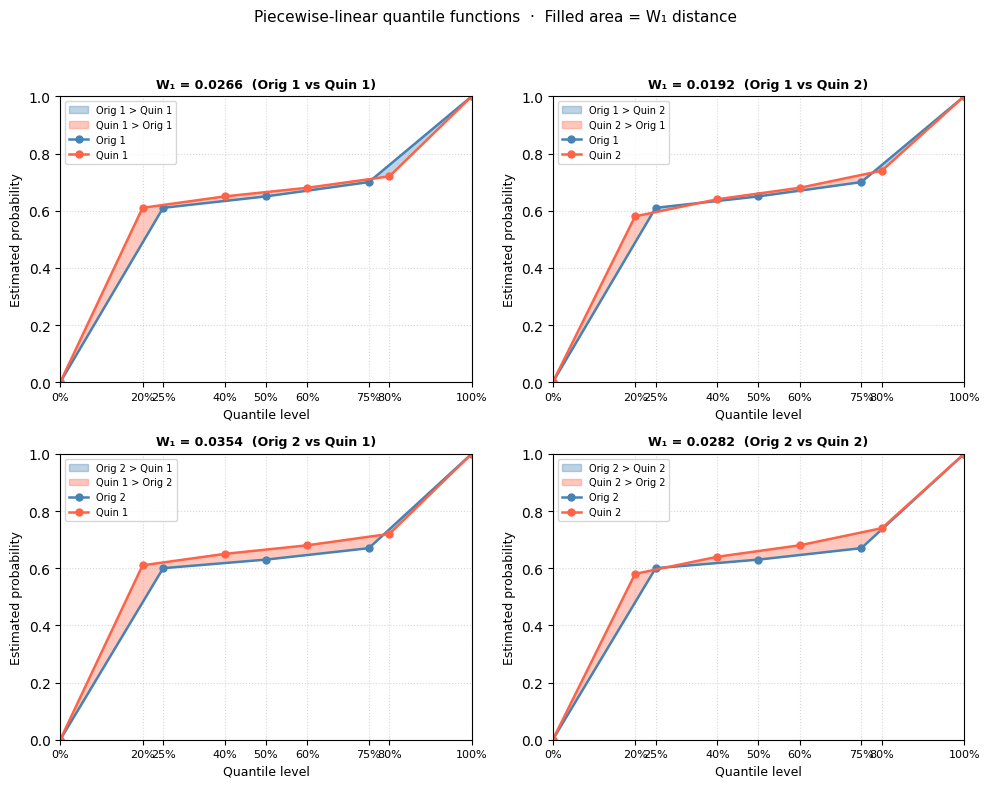

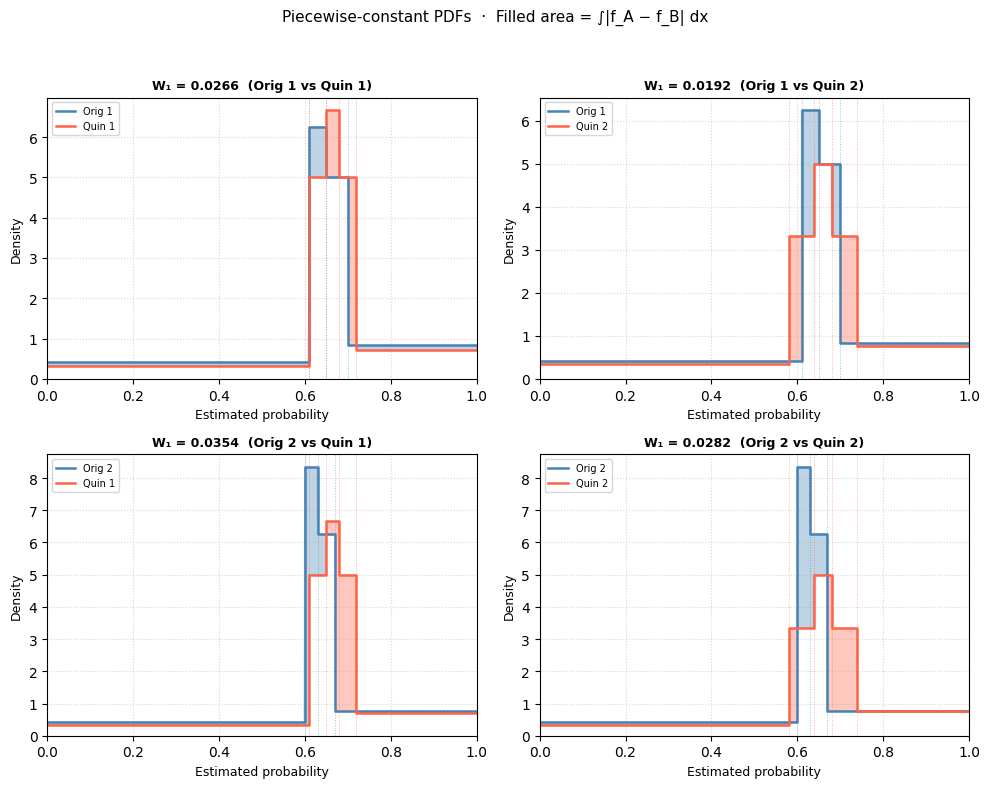

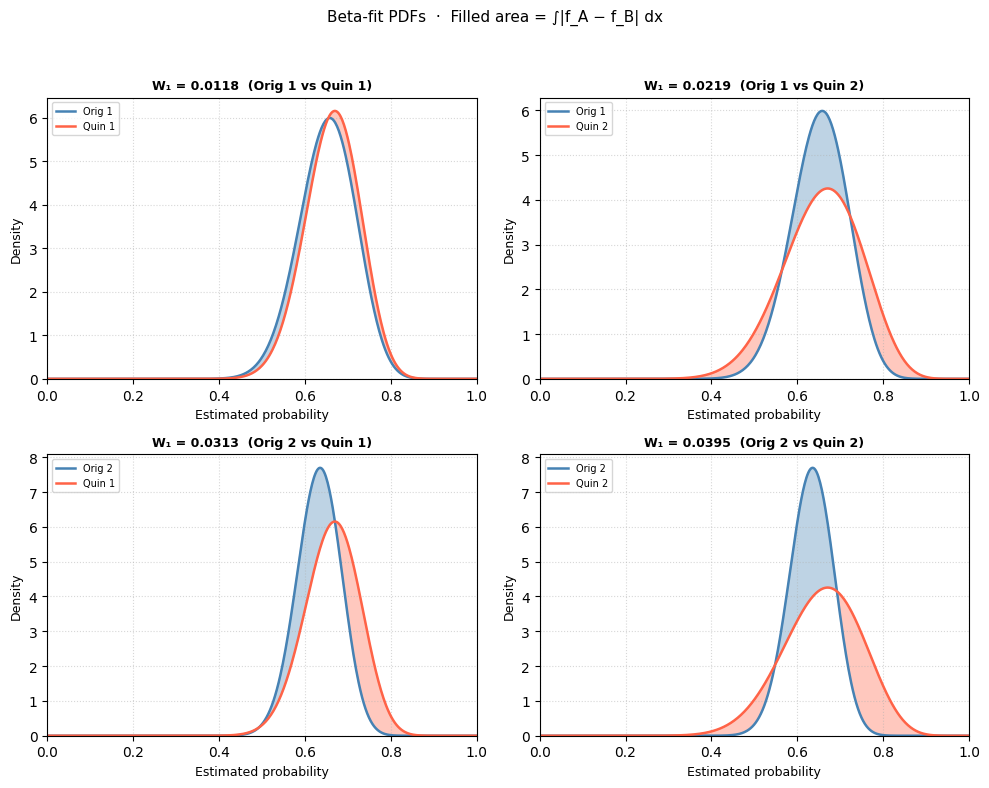

In [7]:

subset_cl = df[
    (df["model"] == "claude-sonnet-4-6" )  &
    (df["step_name"] == "TA0001 - Initial Access")
]

subset_quin = df_quintiles[
    (df_quintiles["model"] == "claude-sonnet-4-6" )  &
    (df_quintiles["step_name"] == "TA0001 - Initial Access")
]
print(len(subset_cl))
# Convert each subset's rows into lists of (percentile, value) pairs
dists_cl   = subset_cl[0:2].apply(row_to_pairs, axis=1).tolist()
dists_quin = subset_quin[0:2].apply(row_to_pairs, axis=1).tolist()

fig = plot_cdf_pairs(dists_cl, dists_quin, labels_a=['Orig 1','Orig 2'],labels_b=['Quin 1','Quin 2'])
fig2 = plot_pdf_pairs(dists_cl, dists_quin, labels_a=['Orig 1','Orig 2'],labels_b=['Quin 1','Quin 2'])
fig3 = plot_pdf_pairs(dists_cl, dists_quin, labels_a=['Orig 1','Orig 2'],labels_b=['Quin 1','Quin 2'], use_beta=True)



## Stats comparison
Want to compute the average difference within groups, and the average difference across groups.
I can compute this all in one pass with compute_pairwise_results, or can split it up and do the specific comparisons. The second is probably cleaner.

In [8]:
subset_cl = df[
    (df["model"] == "claude-sonnet-4-6" )
]

subset_quin = df_quintiles[
    (df_quintiles["model"] == "claude-sonnet-4-6" )
]

# Want to compare within model + step, so need to split these further. 
steps = sorted(set(subset_cl["step_name"].unique()) | set(subset_quin["step_name"].unique()))

cross_results = {}    # quin vs cl, per step
within_cl_results = {}
within_quin_results = {}

for step in steps:
    cl_step = subset_cl[subset_cl["step_name"] == step]
    quin_step = subset_quin[subset_quin["step_name"] == step]

    # Cross-dataframe: quin vs cl
    if len(cl_step) > 0 and len(quin_step) > 0:
        cross_results[step] = compute_pairwise_metrics(cl_step, quin_step, include_beta=False)

    # Within cl alone
    if len(cl_step) > 1:
        within_cl_results[step] = compute_pairwise_metrics(cl_step, include_beta=False)

    # Within quin alone
    if len(quin_step) > 1:
        within_quin_results[step] = compute_pairwise_metrics(quin_step, include_beta=False)

print("=== Cross (cl vs quin) ===")
print(pd.DataFrame(cross_results).T)

print("\n=== Within cl ===")
print(pd.DataFrame(within_cl_results).T)

print("\n=== Within quin ===")
print(pd.DataFrame(within_quin_results).T)




=== Cross (cl vs quin) ===
                               w1        w2  p50_divergence  iqr_divergence  \
TA0001 - Initial Access  0.021825  0.030709          0.0112         0.05055   
TA0002 - Execution       0.030467  0.038133          0.0264         0.03105   
TA0007 - Discovery       0.024180  0.045291          0.0048         0.01725   

                         n_pairs  
TA0001 - Initial Access    100.0  
TA0002 - Execution         100.0  
TA0007 - Discovery         100.0  

=== Within cl ===
                               w1        w2  p50_divergence  iqr_divergence  \
TA0001 - Initial Access  0.008000  0.009577        0.009556        0.014222   
TA0002 - Execution       0.013074  0.015469        0.016000        0.020889   
TA0007 - Discovery       0.006324  0.007846        0.004667        0.016667   

                         n_pairs  
TA0001 - Initial Access     45.0  
TA0002 - Execution          45.0  
TA0007 - Discovery          45.0  

=== Within quin ===
                   

In [ ]:
subset_cl = df[
    (df["model"] == "claude-sonnet-4-6" )
]

subset_quin = df_quintiles[
    (df_quintiles["model"] == "claude-sonnet-4-6" )
]

# Want to compare within model + step, so need to split these further. 
steps = sorted(set(subset_cl["step_name"].unique()) | set(subset_quin["step_name"].unique()))

cross_results = {}    # quin vs cl, per step
within_cl_results = {}
within_quin_results = {}

for step in steps:
    cl_step = subset_cl[subset_cl["step_name"] == step]
    quin_step = subset_quin[subset_quin["step_name"] == step]

    # Cross-dataframe: quin vs cl
    if len(cl_step) > 0 and len(quin_step) > 0:
        cross_results[step] = compute_pairwise_metrics(cl_step, quin_step, compute_ci=True, include_beta=False)

    # Within cl alone
    if len(cl_step) > 1:
        within_cl_results[step] = compute_pairwise_metrics(cl_step, compute_ci=True, include_beta=False)

    # Within quin alone
    if len(quin_step) > 1:
        within_quin_results[step] = compute_pairwise_metrics(quin_step, compute_ci=True, include_beta=False)

print("=== Cross (cl vs quin) ===")
print(pd.DataFrame(cross_results).T[['w1', 'w1_ci_lower', 'w1_ci_upper', 'w2', 'w2_ci_lower', 'w2_ci_upper']])

print("\n=== Within cl ===")
print(pd.DataFrame(within_cl_results).T[['w1', 'w1_ci_lower', 'w1_ci_upper', 'w2', 'w2_ci_lower', 'w2_ci_upper']])

print("\n=== Within quin ===")
print(pd.DataFrame(within_quin_results).T[['w1', 'w1_ci_lower', 'w1_ci_upper', 'w2', 'w2_ci_lower', 'w2_ci_upper']])


=== Cross (cl vs quin) ===
                               w1        w2  p50_divergence  iqr_divergence  \
TA0001 - Initial Access  0.021825  0.030709          0.0112         0.05055   
TA0002 - Execution       0.030467  0.038133          0.0264         0.03105   
TA0007 - Discovery       0.024180  0.045291          0.0048         0.01725   

                         n_pairs  confidence_level  n_bootstrap  w1_ci_lower  \
TA0001 - Initial Access    100.0              0.95       1000.0     0.020180   
TA0002 - Execution         100.0              0.95       1000.0     0.024891   
TA0007 - Discovery         100.0              0.95       1000.0     0.022870   

                         w1_ci_upper  w2_ci_lower  w2_ci_upper  
TA0001 - Initial Access     0.023912     0.028516     0.033478  
TA0002 - Execution          0.036183     0.032223     0.044325  
TA0007 - Discovery          0.025645     0.042526     0.048154  

=== Within cl ===
                               w1        w2  p50_diverge

Cleaner visualization of those metrics

In [12]:
def fmt_ci(df, metric):
    return df[metric].map(lambda v: f"{v:.3f}") + " (" + df[f"{metric}_ci_lower"].map(lambda v: f"{v:.3f}") + "–" + df[f"{metric}_ci_upper"].map(lambda v: f"{v:.3f}") + ")"

def print_compact(label, results):
    df = pd.DataFrame(results).T
    out = pd.DataFrame(index=df.index)
    out["w1 (95% CI)"] = fmt_ci(df, "w1")
    out["w2 (95% CI)"] = fmt_ci(df, "w2")
    print(f"=== {label} ===")
    print(out.to_string())
    print()

print_compact("Cross (cl vs quin)", cross_results)
print_compact("Within cl", within_cl_results)
print_compact("Within quin", within_quin_results)


=== Cross (cl vs quin) ===
                                 w1 (95% CI)          w2 (95% CI)
TA0001 - Initial Access  0.022 (0.020–0.024)  0.031 (0.029–0.033)
TA0002 - Execution       0.030 (0.025–0.036)  0.038 (0.032–0.044)
TA0007 - Discovery       0.024 (0.023–0.026)  0.045 (0.043–0.048)

=== Within cl ===
                                 w1 (95% CI)          w2 (95% CI)
TA0001 - Initial Access  0.008 (0.005–0.010)  0.010 (0.006–0.011)
TA0002 - Execution       0.013 (0.008–0.015)  0.015 (0.010–0.017)
TA0007 - Discovery       0.006 (0.004–0.007)  0.008 (0.005–0.009)

=== Within quin ===
                                 w1 (95% CI)          w2 (95% CI)
TA0001 - Initial Access  0.019 (0.011–0.021)  0.024 (0.013–0.027)
TA0002 - Execution       0.022 (0.013–0.024)  0.024 (0.015–0.027)
TA0007 - Discovery       0.006 (0.003–0.007)  0.007 (0.004–0.009)



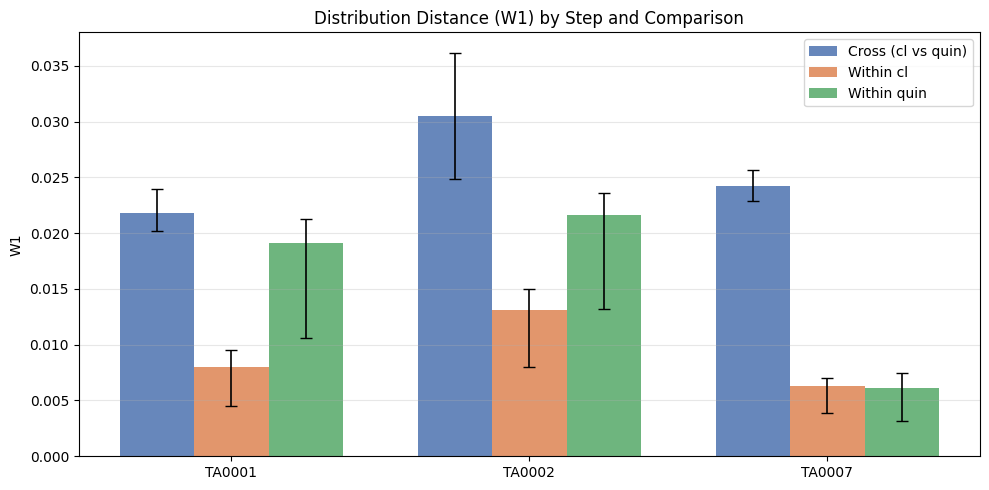

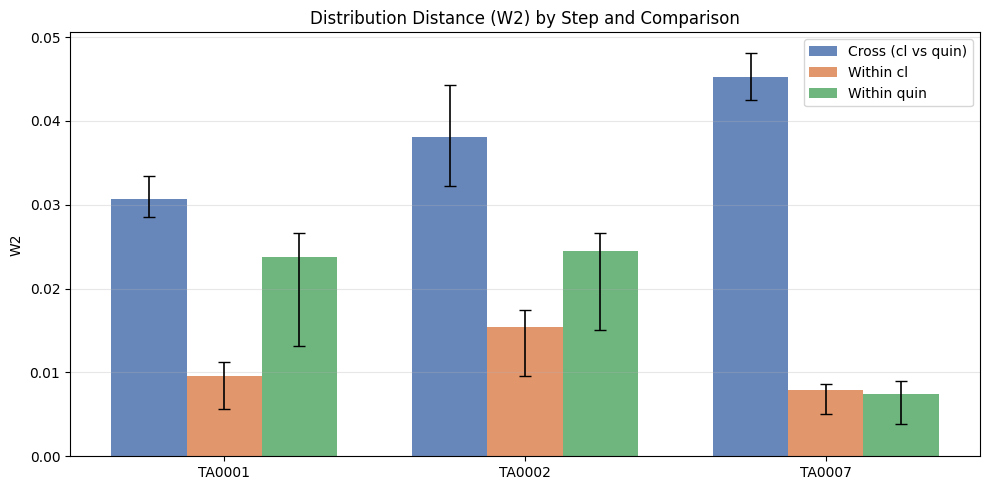

In [13]:
def plot_distances(cross_results, within_cl_results, within_quin_results, metric="w1"):
    groups = {
        "Cross (cl vs quin)": cross_results,
        "Within cl": within_cl_results,
        "Within quin": within_quin_results,
    }
    colors = ["#4C72B0", "#DD8452", "#55A868"]

    # Collect all steps in a consistent order
    all_steps = sorted(set().union(*[r.keys() for r in groups.values()]))
    x = np.arange(len(all_steps))
    n_groups = len(groups)
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, (label, results, color) in enumerate(zip(groups.keys(), groups.values(), colors)):
        vals, errs_lo, errs_hi = [], [], []
        for step in all_steps:
            if step in results:
                r = results[step]
                vals.append(r[metric])
                errs_lo.append(r[metric] - r[f"{metric}_ci_lower"])
                errs_hi.append(r[f"{metric}_ci_upper"] - r[metric])
            else:
                vals.append(np.nan)
                errs_lo.append(0)
                errs_hi.append(0)

        offsets = x + (i - n_groups / 2 + 0.5) * width
        ax.bar(offsets, vals, width=width, label=label, color=color, alpha=0.85)
        ax.errorbar(offsets, vals, yerr=[errs_lo, errs_hi],
                    fmt="none", color="black", capsize=4, linewidth=1.2)

    ax.set_xticks(x)
    ax.set_xticklabels([s.split(" - ")[0] for s in all_steps])  # shorten to tactic ID
    ax.set_ylabel(metric.upper())
    ax.set_title(f"Distribution Distance ({metric.upper()}) by Step and Comparison")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    return fig

fig_w1 = plot_distances(cross_results, within_cl_results, within_quin_results, metric="w1")
fig_w2 = plot_distances(cross_results, within_cl_results, within_quin_results, metric="w2")
